# 02 — PCA, Leiden clustering, quantitative resolution assessment and annotation

This notebook uses the full-gene normalized object from Notebook 1. Only the 2,000 HVGs are used for scaling/PCA/neighborhood construction. The full expression matrix remains available for marker visualization.

Reviewer-facing additions:
- quantitative clustering-resolution assessment using a reproducible silhouette-score sample;
- doublet-filtered cells only;
- canonical marker visualization with discussion of overlapping markers;
- reproducible final resolution choice;
- consistent Figure 2/3 outputs.

In [1]:
from pathlib import Path
import gc
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

SEED = 42
np.random.seed(SEED)

ROOT = Path("..")
RESULTS_DIR = ROOT / "results"
FIG_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

adata = sc.read_h5ad(RESULTS_DIR / "adata_qc_normalized.h5ad")
print(adata)
print("Cells:", adata.n_obs, "Genes:", adata.n_vars)
print("HVGs:", int(adata.var["highly_variable"].sum()))

AnnData object with n_obs × n_vars = 88922 × 11946
    obs: 'sample', 'sex', 'treatment', 'replicate', 'condition', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'sample_batch'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'log1p'
    layers: 'counts'
Cells: 88922 Genes: 11946
HVGs: 2000


## 1. PCA using HVGs only

We scale only the HVGs, avoiding the previous workflow's problem of scaling the expression matrix that will later be used for DE. The DE notebook never uses this scaled matrix.

/home/tanvir-ahmed/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


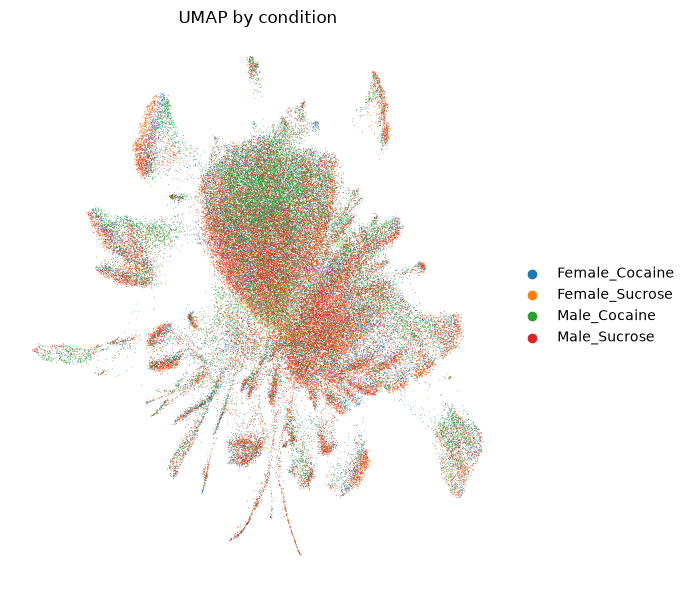

In [2]:
hvg = adata.var["highly_variable"].to_numpy()
adata_hvg = adata[:, hvg].copy()

# Scaling is only for dimensionality reduction.
sc.pp.scale(adata_hvg, max_value=10)
sc.tl.pca(adata_hvg, n_comps=50, svd_solver="arpack", random_state=SEED)

# Transfer PCA coordinates to the full-gene object.
adata.obsm["X_pca"] = adata_hvg.obsm["X_pca"].copy()
adata.uns["pca"] = adata_hvg.uns["pca"].copy()

del adata_hvg
gc.collect()

sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30, random_state=SEED)
sc.tl.umap(adata, random_state=SEED)

fig, ax = plt.subplots(figsize=(7, 6))
sc.pl.umap(adata, color="condition", ax=ax, show=False, frameon=False)
ax.set_title("UMAP by condition")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_umap_condition.png", dpi=180, bbox_inches="tight")
plt.show()

## 2. Quantitative Leiden resolution comparison

A silhouette score is calculated on a fixed random sample of cells in the PCA space. This avoids the quadratic memory cost of calculating a full 89k-cell silhouette score.

The final choice should consider both the score and biological interpretability; the score is not treated as the only criterion.

In [3]:
RESOLUTIONS = [0.5, 0.8, 1.0, 1.2]
rng = np.random.default_rng(SEED)
sample_n = min(5000, adata.n_obs)
sample_idx = rng.choice(adata.n_obs, size=sample_n, replace=False)

resolution_rows = []
for res in RESOLUTIONS:
    key = f"leiden_res_{str(res).replace('.', '_')}"
    sc.tl.leiden(adata, resolution=res, key_added=key, random_state=SEED)
    labels = adata.obs[key].astype(str).to_numpy()[sample_idx]
    X = adata.obsm["X_pca"][sample_idx, :30]
    score = silhouette_score(X, labels, metric="euclidean")
    n_clusters = adata.obs[key].nunique()
    resolution_rows.append({
        "resolution": res,
        "n_clusters": n_clusters,
        "silhouette_score_pca_sample": score,
        "sample_size": sample_n,
    })

resolution_df = pd.DataFrame(resolution_rows)
resolution_df.to_csv(TABLE_DIR / "clustering_resolution_comparison.csv", index=False)
resolution_df

/tmp/ipykernel_5743/14101511.py:9: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=res, key_added=key, random_state=SEED)


,resolution,n_clusters,silhouette_score_pca_sample,sample_size
0,0.5,21,0.083912,5000
1,0.8,29,0.076869,5000
2,1.0,32,0.076761,5000
3,1.2,34,0.078907,5000


Final resolution: 0.8
Final clusters: 29


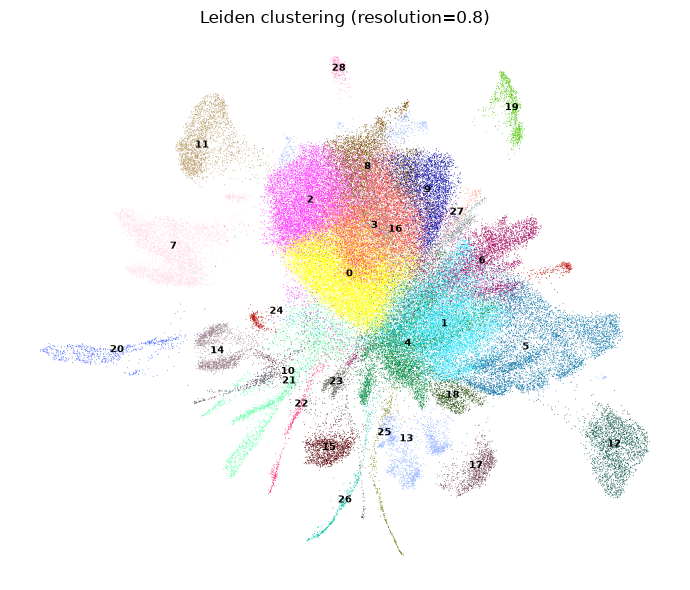

In [4]:
# Select 0.8 as the final resolution only if it remains biologically interpretable.
# This preserves comparability with the original project while documenting the quantitative check.
FINAL_RESOLUTION = 0.8
FINAL_KEY = "leiden_res_0_8"

if FINAL_KEY not in adata.obs:
    sc.tl.leiden(adata, resolution=FINAL_RESOLUTION, key_added=FINAL_KEY, random_state=SEED)

print("Final resolution:", FINAL_RESOLUTION)
print("Final clusters:", adata.obs[FINAL_KEY].nunique())

fig, ax = plt.subplots(figsize=(7, 6))
sc.pl.umap(adata, color=FINAL_KEY, legend_loc="on data", legend_fontsize=7, ax=ax, show=False, frameon=False)
ax.set_title(f"Leiden clustering (resolution={FINAL_RESOLUTION})")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_umap_leiden.png", dpi=180, bbox_inches="tight")
plt.show()

## 3. Canonical marker visualization

Marker overlap is expected in some neuronal populations. We therefore use a panel of canonical markers as **supporting evidence**, not as perfectly exclusive labels.

The project originally used markers including `repo`, `ey`, `Fas2`, `VAChT`, `Gad1`, `ple`, `SerT` and `Tdc2`; the revised plot retains those markers and adds `elav` and `VGlut` where available.

Available markers: ['repo', 'elav', 'ey', 'Fas2', 'VAChT', 'Gad1', 'ple', 'SerT', 'Tdc2']
Missing markers: ['VGlut']

Marker → feature mapping:
repo: ['Dmel_CG31240 repo Gene Expression']
elav: ['Dmel_CG4262 elav Gene Expression']
ey: ['Dmel_CG1464 ey Gene Expression']
Fas2: ['Dmel_CG3665 Fas2 Gene Expression']
VAChT: ['Dmel_CG32848 VAChT Gene Expression']
Gad1: ['Dmel_CG14994 Gad1 Gene Expression']
VGlut: NOT FOUND
ple: ['Dmel_CG10118 ple Gene Expression']
SerT: ['Dmel_CG4545 SerT Gene Expression']
Tdc2: ['Dmel_CG30446 Tdc2 Gene Expression']

Markers used in dotplot: ['repo', 'elav', 'ey', 'Fas2', 'VAChT', 'Gad1', 'ple', 'SerT', 'Tdc2']


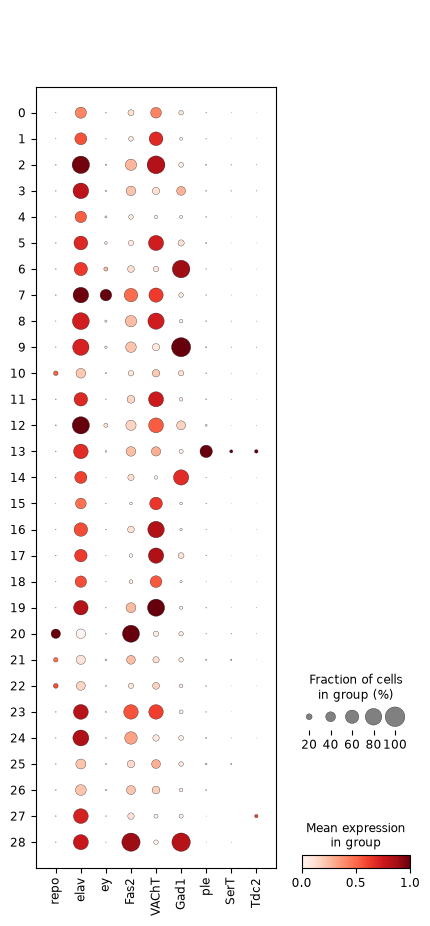


Saved marker expression table to:
../results/tables/cluster_marker_mean_expression.csv


/tmp/ipykernel_5743/3592794436.py:129: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("cluster")[plot_markers]


In [8]:
# ================================================================
# CANONICAL MARKER ANALYSIS
# Reconstruct gene symbols from the existing 10x feature names
# ================================================================

canonical_markers = [
    "repo",
    "elav",
    "ey",
    "Fas2",
    "VAChT",
    "Gad1",
    "VGlut",
    "ple",
    "SerT",
    "Tdc2",
]


# ---------------------------------------------------------------
# 1. Reconstruct gene symbols
# ---------------------------------------------------------------

features = adata.var_names.astype(str)

gene_symbols = (
    features
    .str.replace(r"^Dmel_\S+\s+", "", regex=True)
    .str.replace(r"\s+Gene Expression$", "", regex=True)
)

# Store this annotation in the current AnnData object
adata.var["gene_symbol"] = gene_symbols


# ---------------------------------------------------------------
# 2. Check marker availability
# ---------------------------------------------------------------

available_markers = []
missing_markers = []
marker_features = {}

for marker in canonical_markers:

    matches = list(
        adata.var_names[
            adata.var["gene_symbol"].astype(str) == marker
        ]
    )

    if len(matches) > 0:
        available_markers.append(marker)
        marker_features[marker] = matches
    else:
        missing_markers.append(marker)


print("Available markers:", available_markers)
print("Missing markers:", missing_markers)

print("\nMarker → feature mapping:")
for marker in canonical_markers:
    print(
        f"{marker}: "
        f"{marker_features.get(marker, 'NOT FOUND')}"
    )


# ---------------------------------------------------------------
# 3. Create marker-only copy
# ---------------------------------------------------------------

adata_markers = adata.copy()

adata_markers.var_names = (
    adata_markers.var["gene_symbol"]
    .astype(str)
    .values
)

adata_markers.var_names_make_unique()


# ---------------------------------------------------------------
# 4. Plot canonical markers
# ---------------------------------------------------------------

plot_markers = [
    marker
    for marker in canonical_markers
    if marker in adata_markers.var_names
]

print("\nMarkers used in dotplot:", plot_markers)


if len(plot_markers) > 0:

    sc.pl.dotplot(
        adata_markers,
        var_names=plot_markers,
        groupby=FINAL_KEY,
        standard_scale="var",
        show=False,
    )

    plt.savefig(
        FIG_DIR / "fig3_marker_dotplot.png",
        dpi=180,
        bbox_inches="tight",
    )

    plt.show()


# ---------------------------------------------------------------
# 5. Calculate mean expression by cluster
# ---------------------------------------------------------------

if len(plot_markers) > 0:

    marker_means = (
        adata_markers[:, plot_markers]
        .to_df()
        .assign(
            cluster=adata_markers.obs[FINAL_KEY].values
        )
        .groupby("cluster")[plot_markers]
        .mean()
    )

    marker_means.to_csv(
        TABLE_DIR / "cluster_marker_mean_expression.csv"
    )

    print(
        "\nSaved marker expression table to:"
    )
    print(
        TABLE_DIR / "cluster_marker_mean_expression.csv"
    )

## 4. Explicit cluster annotations

These are intentionally conservative. If a cluster has mixed markers, retain a broad annotation rather than forcing a narrow cell identity.

Edit the dictionary only after inspecting the dotplot and UMAP.

cell_type
Unresolved_cluster_0     11425
Unresolved_cluster_1      9573
Unresolved_cluster_2      8753
Unresolved_cluster_3      8480
Unresolved_cluster_4      6735
Unresolved_cluster_5      6394
Unresolved_cluster_6      4281
Unresolved_cluster_7      4041
Unresolved_cluster_8      3919
Unresolved_cluster_9      3666
Unresolved_cluster_10     2856
Unresolved_cluster_11     2295
Unresolved_cluster_12     2203
Unresolved_cluster_13     2201
Unresolved_cluster_14     1505
Unresolved_cluster_15     1393
Unresolved_cluster_16     1388
Unresolved_cluster_17     1203
Unresolved_cluster_18     1010
Unresolved_cluster_19      887
Unresolved_cluster_20      848
Unresolved_cluster_21      717
Unresolved_cluster_22      615
Unresolved_cluster_23      543
Unresolved_cluster_24      493
Unresolved_cluster_25      458
Unresolved_cluster_26      452
Unresolved_cluster_27      298
Unresolved_cluster_28      290
Name: count, dtype: int64


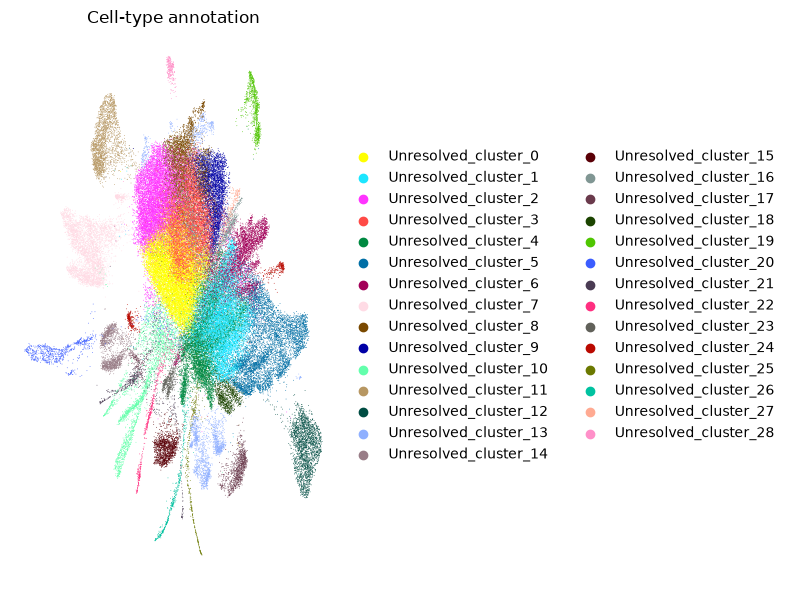

In [9]:
# Conservative starting labels. Change cluster IDs only after inspecting fig3_marker_dotplot.png.
# The code keeps the original Leiden IDs if no label is supplied.
cluster_annotation = {
    # Example:
    # "0": "Glial",
    # "1": "Kenyon cell",
    # "2": "Cholinergic neuron",
}

adata.obs["cell_type"] = adata.obs[FINAL_KEY].astype(str).map(cluster_annotation)
adata.obs["cell_type"] = adata.obs["cell_type"].fillna(
    "Unresolved_cluster_" + adata.obs[FINAL_KEY].astype(str)
)

print(adata.obs["cell_type"].value_counts())

fig, ax = plt.subplots(figsize=(8, 6))
sc.pl.umap(adata, color="cell_type", legend_loc="right margin", ax=ax, show=False, frameon=False)
ax.set_title("Cell-type annotation")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_umap_cell_types.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Save the clustered object

The count layer is preserved. The full-gene log-normalized matrix is preserved in `X`. No scaled matrix is written back to `X`, preventing accidental reuse of scaled values for DE.

In [10]:
adata.write_h5ad(RESULTS_DIR / "adata_clustered.h5ad", compression="gzip")
print("Saved:", RESULTS_DIR / "adata_clustered.h5ad")
print("Resolution summary:")
print(resolution_df.to_string(index=False))

Saved: ../results/adata_clustered.h5ad
Resolution summary:
 resolution  n_clusters  silhouette_score_pca_sample  sample_size
        0.5          21                     0.083912         5000
        0.8          29                     0.076869         5000
        1.0          32                     0.076761         5000
        1.2          34                     0.078907         5000


### Reviewer coverage

This notebook addresses the clustering-resolution and marker-interpretation concerns and ensures that the scaled matrix used for PCA is not the matrix used for differential-expression effect sizes.